# Predicting Fetal Distress: Classifying Fetal Health from Cardiotocography Data

**Author:** Angela Mukami, Catherine Nanjala, Moffat Mwangi, Tafford Pessah

---

## 1. Business Understanding

Monitoring fetal health during pregnancy is critical to ensure both maternal and fetal well-being. One of the most common methods for evaluating fetal health is Cardiotocography (CTG), which measures fetal heart rate and uterine contractions. Abnormalities in CTG readings can indicate potential fetal distress, requiring immediate intervention to prevent complications during labour and delivery.

However, interpreting CTG data is complex and subject to inter-observer variability -- different clinicians can interpret the same trace differently. An automated classification system that reliably identifies fetal distress from CTG measurements could assist healthcare providers in making faster, more consistent decisions.

### The predictive question

> Using Cardiotocography (CTG) measurements -- fetal heart rate patterns, uterine contractions, decelerations, and variability indicators -- can we classify fetal health status as Normal, Suspected, or Abnormal?

This would be useful because early and accurate classification of fetal health enables timely clinical intervention for high-risk pregnancies, potentially reducing adverse outcomes for both mother and baby.

### Who would use this?

- **Healthcare providers**: An automated tool to assist in interpreting CTG data, enabling faster assessment of fetal health and more consistent decision-making across clinicians.
- **Medical researchers**: Exploring which CTG measurements are most strongly associated with fetal distress, advancing knowledge in obstetrics and maternal-fetal medicine.
- **Hospital systems**: Reducing unnecessary interventions by accurately distinguishing normal cases from those requiring action, while ensuring genuinely at-risk cases are not missed.

### Domain context

Cardiotocography has been a standard tool in obstetric care since the 1960s. While it is widely used, its interpretation remains subjective. Studies have shown significant inter-observer and intra-observer variability in CTG interpretation, which can lead to both over-intervention (unnecessary caesarean sections) and under-intervention (missed fetal distress). Machine learning approaches to CTG classification aim to reduce this variability by providing consistent, data-driven assessments.

A critical consideration in this domain is the asymmetry of errors. In clinical terms, a false negative on an Abnormal case -- classifying a distressed fetus as normal -- is far more dangerous than a false positive. This shapes our evaluation strategy: we prioritise recall on the Abnormal class over raw accuracy.

Source: Ayres-de-Campos, D., et al. (2015). FIGO consensus guidelines on intrapartum fetal monitoring: Cardiotocography. International Journal of Gynecology & Obstetrics, 131(1), 13-24.

## 2. Data Understanding

### 2.1 Imports and setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)

print("All imports loaded successfully.")

Matplotlib is building the font cache; this may take a moment.


All imports loaded successfully.


### 2.2 Load the dataset

The dataset contains 2,126 Cardiotocography (CTG) records. Each record includes 21 features measuring fetal heart rate patterns, uterine contractions, decelerations, variability indicators, and histogram-derived statistics. The target variable is fetal health status classified into three categories.

In [8]:
df = pd.read_csv('fetal_health.csv')
print(f"Dataset shape: {df.shape[0]} records, {df.shape[1]} columns")
df.head()

Dataset shape: 2126 records, 22 columns


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


### 2.3 Initial data inspection

In [9]:
print("Column names and data types:")
print(df.dtypes)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values found.")

Column names and data types:
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                      

In [10]:
print("Descriptive statistics:\n")
df.describe().round(2)

Descriptive statistics:



,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,8.19,70.45,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,5.63,38.96,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,0.00,3.00,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,4.60,37.00,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,7.40,67.50,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,10.80,100.00,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,50.70,180.00,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,3.00


### 2.4 Target variable distribution

In [11]:
target_counts = df['fetal_health'].value_counts().sort_index()
target_pcts = (df['fetal_health'].value_counts(normalize=True).sort_index() * 100).round(1)

label_map = {1.0: 'Normal', 2.0: 'Suspected', 3.0: 'Abnormal'}

print("Fetal Health Class Distribution:")
print("-" * 40)
for cls in [1.0, 2.0, 3.0]:
    print(f"  {label_map[cls]} (Class {int(cls)}): {target_counts[cls]} records ({target_pcts[cls]}%)")
print(f"\nTotal records: {len(df)}")

Fetal Health Class Distribution:
----------------------------------------
  Normal (Class 1): 1655 records (77.8%)
  Suspected (Class 2): 295 records (13.9%)
  Abnormal (Class 3): 176 records (8.3%)

Total records: 2126


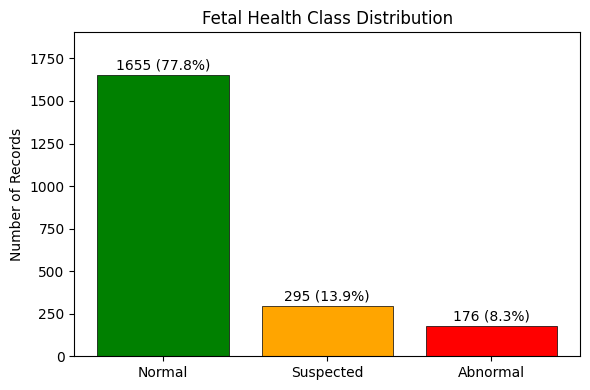

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['green', 'orange', 'red']
class_names = ['Normal', 'Suspected', 'Abnormal']
counts = [target_counts[c] for c in [1.0, 2.0, 3.0]]

bars = ax.bar(class_names, counts, color=colors, edgecolor='black', linewidth=0.5)

for bar, count, pct in zip(bars, counts, [target_pcts[c] for c in [1.0, 2.0, 3.0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{count} ({pct}%)", ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of Records')
ax.set_title('Fetal Health Class Distribution')
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

The dataset has a severe class imbalance. Normal cases dominate at 77.8%, Suspected cases make up 13.9%, and Abnormal cases are only 8.3% of the data. This imbalance is typical of clinical datasets -- most pregnancies are healthy, and pathological cases are relatively rare.

This has important implications for modelling:

- A naive model that predicts "Normal" for every case would achieve roughly 78% accuracy -- our models must substantially beat this baseline.
- Accuracy alone is misleading. We will use macro F1 as the primary comparison metric, which weights all three classes equally.
- We pay special attention to recall on the Abnormal class (Class 3), because in a clinical setting, missing a case of fetal distress is far more dangerous than a false alarm.


### 2.5 Correlation analysis

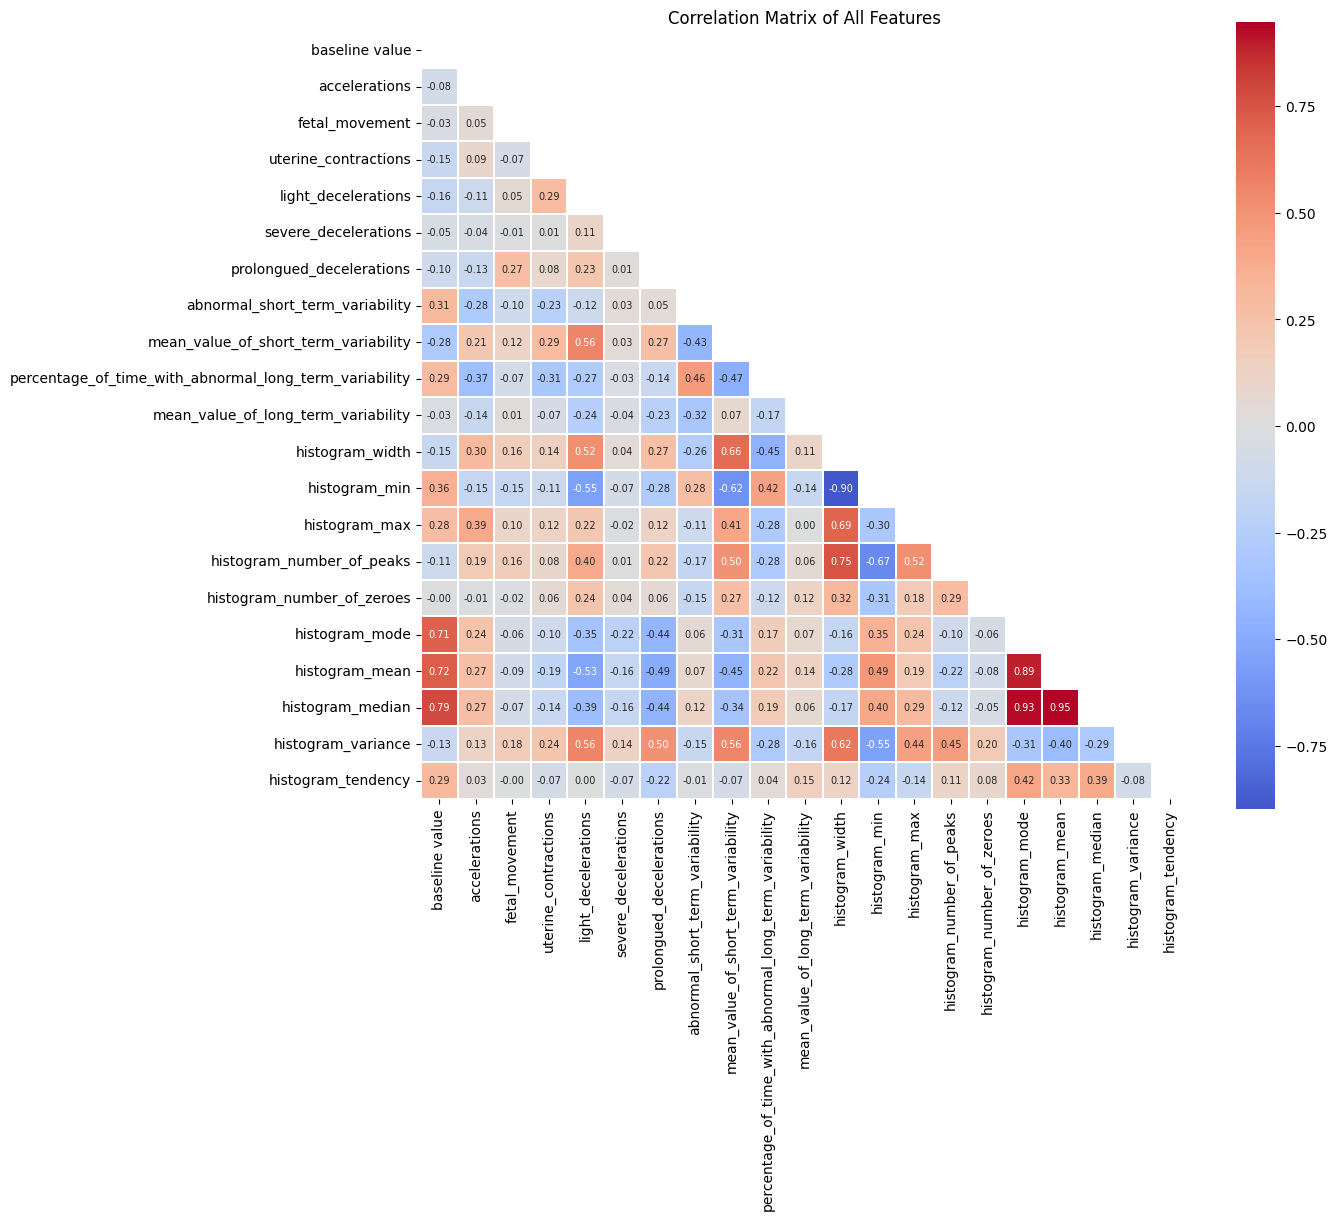

In [13]:
fig, ax = plt.subplots(figsize=(14, 12))
feature_cols = [c for c in df.columns if c != 'fetal_health']
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

In [14]:
# Flag highly correlated pairs (above 0.85 threshold)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.85):")
    for c1, c2, r in high_corr_pairs:
        print(f"  {c1} -- {c2}: {r:.3f}")
else:
    print("No feature pairs exceed the 0.85 correlation threshold.")

print("\nTop 10 correlations:")
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j], abs(corr.iloc[i, j])))
pairs.sort(key=lambda x: x[2], reverse=True)
for c1, c2, r in pairs[:10]:
    print(f"  {c1} -- {c2}: {r:.3f}")

Highly correlated feature pairs (|r| > 0.85):
  histogram_width -- histogram_min: -0.899
  histogram_mode -- histogram_mean: 0.893
  histogram_mode -- histogram_median: 0.933
  histogram_mean -- histogram_median: 0.948

Top 10 correlations:
  histogram_mean -- histogram_median: 0.948
  histogram_mode -- histogram_median: 0.933
  histogram_width -- histogram_min: 0.899
  histogram_mode -- histogram_mean: 0.893
  baseline value -- histogram_median: 0.789
  histogram_width -- histogram_number_of_peaks: 0.747
  baseline value -- histogram_mean: 0.723
  baseline value -- histogram_mode: 0.709
  histogram_width -- histogram_max: 0.691
  histogram_min -- histogram_number_of_peaks: 0.670


The correlation analysis reveals expected redundancy among the histogram features. As anticipated, histogram_mean, histogram_median, and histogram_mode are highly correlated with each other -- these all describe the central tendency of the same fetal heart rate distribution. We will address this redundancy in the data preparation phase by dropping features that exceed our 0.85 correlation threshold.

The correlation matrix also shows that most clinical features (accelerations, decelerations, variability measures) are not highly correlated with each other, suggesting they capture different aspects of fetal health and are worth retaining.

## 3. Data Preparation

### 3.1 Handle highly correlated features

We drop one feature from each pair that exceeds the 0.85 correlation threshold. When choosing which to drop, we prefer to keep the feature that is more clinically interpretable or more commonly used.

In [15]:
# Drop redundant features based on correlation analysis
# We keep a running list and remove features that are redundant
features_to_drop = []

for c1, c2, r in high_corr_pairs:
    # If neither has been dropped yet, drop the less interpretable one
    if c1 not in features_to_drop and c2 not in features_to_drop:
        # Prefer to keep: histogram_mean over histogram_median/mode (more standard)
        # Prefer to keep: histogram_max over histogram_min when paired with width
        # General rule: drop the second in the pair
        features_to_drop.append(c2)
        print(f"Dropping '{c2}' (correlated with '{c1}', r={r:.3f})")

print(f"\nTotal features dropped: {len(features_to_drop)}")

# Create modelling dataframe
df_model = df.drop(columns=features_to_drop)
remaining_features = [c for c in df_model.columns if c != 'fetal_health']
print(f"Remaining features ({len(remaining_features)}): {remaining_features}")

Dropping 'histogram_min' (correlated with 'histogram_width', r=-0.899)
Dropping 'histogram_mean' (correlated with 'histogram_mode', r=0.893)
Dropping 'histogram_median' (correlated with 'histogram_mode', r=0.933)

Total features dropped: 3
Remaining features (18): ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_variance', 'histogram_tendency']


### 3.2 Prepare features and target

In [16]:
# Separate features and target
X = df_model[remaining_features]
y = df_model['fetal_health'].astype(int)

# Map target labels for display
label_map = {1: 'Normal', 2: 'Suspected', 3: 'Abnormal'}
print(f"Features shape: {X.shape}")
print(f"Target classes: {label_map}")
print(f"\nTarget distribution:")
for cls in [1, 2, 3]:
    count = (y == cls).sum()
    print(f"  {label_map[cls]} (Class {cls}): {count} ({count/len(y)*100:.1f}%)")

Features shape: (2126, 18)
Target classes: {1: 'Normal', 2: 'Suspected', 3: 'Abnormal'}

Target distribution:
  Normal (Class 1): 1655 (77.8%)
  Suspected (Class 2): 295 (13.9%)
  Abnormal (Class 3): 176 (8.3%)


### 3.3 Train/test split and scaling

In [17]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
for cls in [1, 2, 3]:
    count = (y_train == cls).sum()
    print(f"  {label_map[cls]}: {count} ({count/len(y_train)*100:.1f}%)")

Training set: 1700 samples
Test set:     426 samples

Training target distribution:
  Normal: 1323 (77.8%)
  Suspected: 236 (13.9%)
  Abnormal: 141 (8.3%)


In [18]:
# Scale features for models that need it (Logistic Regression, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete (StandardScaler fitted on training data only).")

Feature scaling complete (StandardScaler fitted on training data only).


### 3.4 Establish the baseline

A model that simply predicts "Normal" for every case would achieve this accuracy. Every model we build must substantially exceed this to demonstrate it is learning genuine patterns.

In [19]:
majority_pct = max(np.bincount(y_train)[1:]) / len(y_train)
print(f"Majority class baseline accuracy: {majority_pct:.3f}")
print(f"\nThis means any model below {majority_pct:.1%} accuracy is performing")
print("worse than simply predicting 'Normal' every time.")
print("\nImportantly, such a model would have ZERO recall on Suspected and Abnormal")
print("cases -- it would miss every case of potential fetal distress.")

Majority class baseline accuracy: 0.778

This means any model below 77.8% accuracy is performing
worse than simply predicting 'Normal' every time.

Importantly, such a model would have ZERO recall on Suspected and Abnormal
cases -- it would miss every case of potential fetal distress.


## 4. Modelling

We train and evaluate five classifiers, progressing from simple to complex. For each model we report:
- 5-fold stratified cross-validation scores (to confirm stability)
- Test set accuracy and macro F1 score
- Confusion matrix
- Full classification report (precision, recall, F1 per class)
- Recall on Abnormal class (Class 3) -- the most clinically important metric

We store results as we go for final comparison.

In [20]:
# Set up cross-validation strategy and results storage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
class_names = ['Normal', 'Suspected', 'Abnormal']
all_results = {}

### 4.1 Model 1: Logistic Regression

Logistic Regression is our interpretable baseline. It provides coefficient-based insight into which features push toward each class. We use it to establish whether a simple linear model can learn meaningful patterns from CTG data.

In [21]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')

# 5-fold cross-validation
lr_cv_acc = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
lr_cv_f1 = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')

print("Logistic Regression -- 5-Fold Cross-Validation")
print("-" * 50)
print(f"Accuracy:  {lr_cv_acc.mean():.3f} (+/- {lr_cv_acc.std():.3f})")
print(f"Macro F1:  {lr_cv_f1.mean():.3f} (+/- {lr_cv_f1.std():.3f})")
print(f"Baseline:  {majority_pct:.3f}")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [22]:
# Fit on full training set and evaluate on test set
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print("Logistic Regression -- Test Set Performance")
print("-" * 50)
print(f"Accuracy:  {lr_acc:.3f}")
print(f"Macro F1:  {lr_f1:.3f}")

all_results['Logistic Regression'] = {
    'model': lr_model,
    'y_pred': lr_preds,
    'accuracy': lr_acc,
    'macro_f1': lr_f1,
    'cv_acc': lr_cv_acc.mean(),
    'cv_f1': lr_cv_f1.mean()
}

NameError: name 'lr_model' is not defined

NameError: name 'lr_preds' is not defined

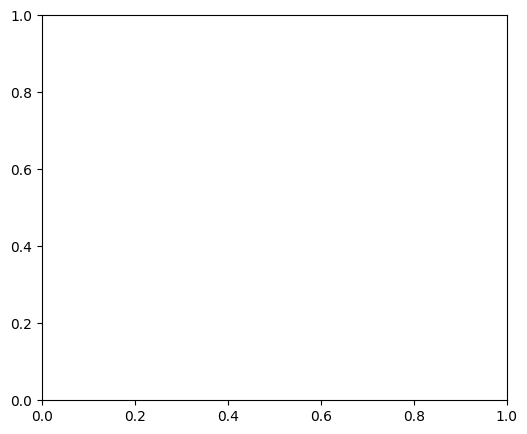

In [23]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Logistic Regression\nAccuracy: {lr_acc:.3f} | Macro F1: {lr_f1:.3f}')
plt.tight_layout()
plt.show()

In [24]:
# Classification report
print("Logistic Regression -- Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=class_names))

Logistic Regression -- Classification Report


NameError: name 'lr_preds' is not defined